In [2]:
import json
import random
import csv
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
all_data = json.load(open('./raw_data.json', 'r'))

In [4]:
len(all_data)

820

In [5]:
data = []
check_double = set()
for entry in all_data:
    unique_key = entry['workerId'] + entry['taskId']
    if unique_key in check_double:
        continue
    check_double.add(unique_key)
    if entry['task'] == 'classify' and entry['ab'] == 'A':
        data.extend(dict(item, worker=entry['workerId']) for item in entry['items'])

In [6]:
EMOJI = sorted({choice['code'] for row in data for choice in row['choices']})
faces = sorted(set(row['file'] for row in data))

In [7]:
len(data), len(EMOJI), len(faces)

(3600, 68, 20)

In [8]:
print(np.mean([row['sample']>1 for row in data]))

0.19666666666666666


In [94]:
def get_data(data, face):
    return [
        {
            "choices": [EMOJI.index(choice['code']) for choice in row['choices']],
            "selected": EMOJI.index(row['choices'][row['selected']]['code'])
        }
        for row in data if row['file'] == face
    ]

In [95]:
def loss(DATA, x):
        denom_mat = np.zeros((len(DATA),x.shape[0]))
        num_mat = np.zeros((len(DATA),x.shape[0]))
        for i in range(len(DATA)):
            denom_mat[i, DATA[i]['choices']] = 1.0
            num_mat[i, DATA[i]['selected']] = 1.0
        exp_x = tf.exp(x)
        loss = -tf.reduce_sum(
            tf.math.log(
                tf.linalg.matmul(num_mat, exp_x) / 
                tf.linalg.matmul(denom_mat, exp_x)))
        return loss

In [96]:
def fit_model(data):
    RESULT = np.zeros((len(faces), len(EMOJI)))
    for f in range(len(faces)):
        face = faces[f]
        x = tf.Variable(np.zeros((len(EMOJI),1)))
        DATA= get_data(data, face)
        opt = tf.keras.optimizers.Adam(learning_rate = 0.1, epsilon=0.01)
        with tf.GradientTape(persistent=True) as tape:
            L = lambda: loss(DATA,x)
        print(f"{face=}: ", end="")
        for epoch in range(10):
            print(f".", end="")
            x_old = np.exp(x.numpy())
            for iter in range(100):
                opt.minimize(L, [x], tape=tape)
                x.assign(x - tf.math.reduce_max(x))
            dist = np.max(np.abs(x_old - np.exp(x.numpy())))/np.sum(np.exp(x_old))
            if dist < 0.0001:
                break
        print()
        x_opt = np.round(np.exp(x.numpy())/np.sum(np.exp(x.numpy())), 4)
        RESULT[f,:] = np.squeeze(x_opt)
    return RESULT


In [97]:
RESULT = fit_model(data)
with open('gen/resultA.json', 'w') as out:
    json.dump({
        faces[i] : {
            "x_opt" : {"%0x" % EMOJI[j] : RESULT[i][j] for j in range(len(EMOJI))},
        }
        for i in range(len(faces))
    }, out, indent=2)

face='img_align_celeba/000838.jpg': ...
face='img_align_celeba/012499.jpg': ...
face='img_align_celeba/024857.jpg': ..
face='img_align_celeba/029376.jpg': ...
face='img_align_celeba/036568.jpg': ..
face='img_align_celeba/090689.jpg': ..
face='img_align_celeba/092099.jpg': ..
face='img_align_celeba/093560.jpg': ..
face='img_align_celeba/106786.jpg': ..
face='img_align_celeba/117396.jpg': ..
face='img_align_celeba/128198.jpg': ..
face='img_align_celeba/153630.jpg': ..
face='img_align_celeba/167840.jpg': ...
face='img_align_celeba/168485.jpg': ...
face='img_align_celeba/173110.jpg': ...
face='img_align_celeba/181029.jpg': ..
face='img_align_celeba/195696.jpg': ...
face='lfw/Joe_Lieberman/Joe_Lieberman_0009.jpg': ...
face='lfw/Ruano_Pascual/Ruano_Pascual_0001.jpg': ..
face='lfw/Saman_Shali/Saman_Shali_0001.jpg': ..


In [98]:
len(set([np.argmax(RESULT[i]) for i in range(len(faces))]))

11

# Bayesian decoding

In [18]:
workers = np.random.permutation(sorted(set(row['worker'] for row in data)))
selected = { workers[i] : i < len(workers)//2 for i in range(len(workers)) } 

In [19]:
data1 = [row for row in data if selected[row['worker']]]
data2 = [row for row in data if not selected[row['worker']]]
Result1 = fit_model(data1)
Result2 = fit_model(data2)

face='img_align_celeba/000838.jpg': .......
face='img_align_celeba/012499.jpg': ..........
face='img_align_celeba/024857.jpg': ......
face='img_align_celeba/029376.jpg': .....
face='img_align_celeba/036568.jpg': ..........
face='img_align_celeba/090689.jpg': ....
face='img_align_celeba/092099.jpg': .......
face='img_align_celeba/093560.jpg': ...
face='img_align_celeba/106786.jpg': ..........
face='img_align_celeba/117396.jpg': .......
face='img_align_celeba/128198.jpg': ....
face='img_align_celeba/153630.jpg': ....
face='img_align_celeba/167840.jpg': .........
face='img_align_celeba/168485.jpg': ...
face='img_align_celeba/173110.jpg': ..........
face='img_align_celeba/181029.jpg': ...
face='img_align_celeba/195696.jpg': ..........
face='lfw/Joe_Lieberman/Joe_Lieberman_0009.jpg': ........
face='lfw/Ruano_Pascual/Ruano_Pascual_0001.jpg': ..........
face='lfw/Saman_Shali/Saman_Shali_0001.jpg': ..........
face='img_align_celeba/000838.jpg': .....
face='img_align_celeba/012499.jpg': .......

In [32]:
total = 0
successes = 0
y = 5
for i in range(len(faces)):
    e_star = np.argmax(Result1[i])
    ti, si = 0,0
    for j in range(500):
        decoys = np.random.choice(range(len(faces)), y, replace=True)
        if Result1[i][e_star] < np.max(Result2[decoys, e_star]):
            success = 0
        else:
            success = 1/(1+np.sum(Result2[i][e_star] == Result2[decoys, e_star]))
        si += success
        ti += 1
    print(f"{i+1:2d} {faces[i]:41s}: {100 * si/ti:6.2f}")
    total += ti
    successes += si

 1 img_align_celeba/000838.jpg              :  19.42
 2 img_align_celeba/012499.jpg              :  87.37
 3 img_align_celeba/024857.jpg              :  88.97
 4 img_align_celeba/029376.jpg              :  19.76
 5 img_align_celeba/036568.jpg              :  69.13
 6 img_align_celeba/090689.jpg              :  22.34
 7 img_align_celeba/092099.jpg              :  62.71
 8 img_align_celeba/093560.jpg              :  21.07
 9 img_align_celeba/106786.jpg              :  18.44
10 img_align_celeba/117396.jpg              :  21.97
11 img_align_celeba/128198.jpg              :  18.53
12 img_align_celeba/153630.jpg              :  78.10
13 img_align_celeba/167840.jpg              :  18.69
14 img_align_celeba/168485.jpg              :  14.80
15 img_align_celeba/173110.jpg              :  19.48
16 img_align_celeba/181029.jpg              :  67.32
17 img_align_celeba/195696.jpg              :  20.85
18 lfw/Joe_Lieberman/Joe_Lieberman_0009.jpg :  20.43
19 lfw/Ruano_Pascual/Ruano_Pascual_0001.jpg : 

In [33]:
print(f"{successes}/{total} = {100*successes/total:.2f}")
print(f"M={y/(total/successes-1):.2f}")

3941.450000000005/10000 = 39.41
M=3.25


In [34]:
len(set([np.argmax(Result1[i]) for i in range(len(faces))]))

17

In [93]:
total = 0
successes = 0
y = 5
M = 8
for i in range(20000):
    collisions = 0
    for j in range(y):
        collisions += np.random.randint(M)==0
    total += 1
    successes += 1/(1+collisions)
print(f"{successes:.2f}/{total} = {100*successes/total:.2f}")


14732.77/20000 = 73.66


# Trends

In [59]:
trend_data =\
[{'max_n': 10, 'p': 0.4291666666666667}, {'max_n': 10, 'p': 0.5951666666666666}, {'max_n': 10, 'p': 0.4109166666666667}, {'max_n': 10, 'p': 0.4032083333333333}, {'max_n': 10, 'p': 0.4165416666666667}, {'max_n': 10, 'p': 0.46495833333333336}, {'max_n': 10, 'p': 0.46858333333333335}, {'max_n': 10, 'p': 0.502625}, {'max_n': 10, 'p': 0.37837499999999996}, {'max_n': 10, 'p': 0.43491666666666673}, {'max_n': 10, 'p': 0.42320833333333335}, {'max_n': 10, 'p': 0.4525416666666668}, {'max_n': 10, 'p': 0.44916666666666666}, {'max_n': 10, 'p': 0.4718333333333332}, {'max_n': 10, 'p': 0.425375}, {'max_n': 10, 'p': 0.42333333333333334}, {'max_n': 10, 'p': 0.6248333333333332}, {'max_n': 10, 'p': 0.3635833333333334}, {'max_n': 10, 'p': 0.43250000000000005}, {'max_n': 10, 'p': 0.37599999999999995}, {'max_n': 10, 'p': 0.4877083333333333}, {'max_n': 10, 'p': 0.4106249999999999}, {'max_n': 10, 'p': 0.4576666666666665}, {'max_n': 10, 'p': 0.3092083333333333}, {'max_n': 10, 'p': 0.4754166666666667}, {'max_n': 20, 'p': 0.5183333333333333}, {'max_n': 20, 'p': 0.6923333333333334}, {'max_n': 20, 'p': 0.6655833333333332}, {'max_n': 20, 'p': 0.6312916666666667}, {'max_n': 20, 'p': 0.6755000000000001}, {'max_n': 20, 'p': 0.5905}, {'max_n': 20, 'p': 0.5220416666666667}, {'max_n': 20, 'p': 0.715875}, {'max_n': 20, 'p': 0.6189583333333334}, {'max_n': 20, 'p': 0.7271666666666667}, {'max_n': 20, 'p': 0.5602083333333333}, {'max_n': 20, 'p': 0.6373333333333334}, {'max_n': 20, 'p': 0.6679166666666666}, {'max_n': 20, 'p': 0.7880416666666666}, {'max_n': 20, 'p': 0.6732916666666666}, {'max_n': 20, 'p': 0.7289583333333333}, {'max_n': 20, 'p': 0.7817083333333334}, {'max_n': 20, 'p': 0.6987083333333334}, {'max_n': 20, 'p': 0.6326250000000001}, {'max_n': 20, 'p': 0.6715833333333333}, {'max_n': 20, 'p': 0.6247500000000001}, {'max_n': 20, 'p': 0.5972916666666667}, {'max_n': 20, 'p': 0.7959166666666667}, {'max_n': 20, 'p': 0.6378750000000001}, {'max_n': 20, 'p': 0.7660000000000001}, {'max_n': 30, 'p': 0.704375}, {'max_n': 30, 'p': 0.6984166666666667}, {'max_n': 30, 'p': 0.7204166666666667}, {'max_n': 30, 'p': 0.6635833333333333}, {'max_n': 30, 'p': 0.7097916666666667}, {'max_n': 30, 'p': 0.6724583333333334}, {'max_n': 30, 'p': 0.7680833333333333}, {'max_n': 30, 'p': 0.7915833333333333}, {'max_n': 30, 'p': 0.6520833333333332}, {'max_n': 30, 'p': 0.7449583333333334}, {'max_n': 30, 'p': 0.7408333333333335}, {'max_n': 30, 'p': 0.7990416666666665}, {'max_n': 30, 'p': 0.6923333333333334}, {'max_n': 30, 'p': 0.7719166666666666}, {'max_n': 30, 'p': 0.667875}, {'max_n': 30, 'p': 0.6952083333333333}, {'max_n': 30, 'p': 0.7007083333333333}, {'max_n': 30, 'p': 0.7752083333333333}, {'max_n': 30, 'p': 0.7302083333333335}, {'max_n': 30, 'p': 0.7369166666666667}, {'max_n': 30, 'p': 0.7348750000000002}, {'max_n': 30, 'p': 0.7467083333333332}, {'max_n': 30, 'p': 0.5702083333333334}, {'max_n': 30, 'p': 0.670375}, {'max_n': 30, 'p': 0.7696666666666667}, {'max_n': 40, 'p': 0.705125}, {'max_n': 40, 'p': 0.7419583333333333}, {'max_n': 40, 'p': 0.748375}, {'max_n': 40, 'p': 0.7618333333333335}, {'max_n': 40, 'p': 0.7587083333333332}, {'max_n': 40, 'p': 0.72625}, {'max_n': 40, 'p': 0.7955000000000001}, {'max_n': 40, 'p': 0.7990416666666669}, {'max_n': 40, 'p': 0.775}, {'max_n': 40, 'p': 0.7875833333333334}, {'max_n': 40, 'p': 0.7485416666666665}, {'max_n': 40, 'p': 0.6087083333333333}, {'max_n': 40, 'p': 0.6664166666666667}, {'max_n': 40, 'p': 0.7562500000000001}, {'max_n': 40, 'p': 0.7420833333333334}, {'max_n': 40, 'p': 0.7422916666666666}, {'max_n': 40, 'p': 0.7658333333333333}, {'max_n': 40, 'p': 0.7059166666666666}, {'max_n': 40, 'p': 0.8127083333333335}, {'max_n': 40, 'p': 0.8210416666666666}, {'max_n': 40, 'p': 0.714375}, {'max_n': 40, 'p': 0.7733333333333333}, {'max_n': 40, 'p': 0.7451666666666665}, {'max_n': 40, 'p': 0.74875}, {'max_n': 40, 'p': 0.6430833333333333}, {'max_n': 50, 'p': 0.6166666666666667}, {'max_n': 50, 'p': 0.7541666666666668}, {'max_n': 50, 'p': 0.7334166666666667}, {'max_n': 50, 'p': 0.7479166666666667}, {'max_n': 50, 'p': 0.7452083333333335}, {'max_n': 50, 'p': 0.728791666666667}, {'max_n': 50, 'p': 0.7540416666666667}, {'max_n': 50, 'p': 0.7141666666666667}, {'max_n': 50, 'p': 0.7360416666666667}, {'max_n': 50, 'p': 0.7220833333333334}, {'max_n': 50, 'p': 0.7664583333333332}, {'max_n': 50, 'p': 0.7684166666666665}, {'max_n': 50, 'p': 0.6347916666666666}, {'max_n': 50, 'p': 0.7529166666666666}, {'max_n': 50, 'p': 0.77475}, {'max_n': 50, 'p': 0.68025}, {'max_n': 50, 'p': 0.715625}, {'max_n': 50, 'p': 0.6575}, {'max_n': 50, 'p': 0.6925}, {'max_n': 50, 'p': 0.6477083333333334}, {'max_n': 50, 'p': 0.765625}, {'max_n': 50, 'p': 0.6690416666666666}, {'max_n': 50, 'p': 0.6670833333333333}, {'max_n': 50, 'p': 0.7485416666666665}, {'max_n': 50, 'p': 0.7089583333333335}, {'max_n': 60, 'p': 0.7562916666666666}, {'max_n': 60, 'p': 0.6592500000000001}, {'max_n': 60, 'p': 0.7808333333333333}, {'max_n': 60, 'p': 0.7445833333333333}, {'max_n': 60, 'p': 0.7633333333333334}, {'max_n': 60, 'p': 0.6760416666666665}, {'max_n': 60, 'p': 0.7935416666666667}, {'max_n': 60, 'p': 0.7185416666666665}, {'max_n': 60, 'p': 0.6989583333333332}, {'max_n': 60, 'p': 0.746625}, {'max_n': 60, 'p': 0.7225}, {'max_n': 60, 'p': 0.6695833333333333}, {'max_n': 60, 'p': 0.7189583333333335}, {'max_n': 60, 'p': 0.7608333333333333}, {'max_n': 60, 'p': 0.7166666666666666}, {'max_n': 60, 'p': 0.61875}, {'max_n': 60, 'p': 0.6819583333333334}, {'max_n': 60, 'p': 0.7187500000000001}, {'max_n': 60, 'p': 0.743125}, {'max_n': 60, 'p': 0.7075}, {'max_n': 60, 'p': 0.67875}, {'max_n': 60, 'p': 0.6816666666666668}, {'max_n': 60, 'p': 0.6658333333333334}, {'max_n': 60, 'p': 0.7539583333333333}, {'max_n': 60, 'p': 0.6980000000000001}, {'max_n': 70, 'p': 0.7275000000000001}, {'max_n': 70, 'p': 0.6852083333333333}, {'max_n': 70, 'p': 0.730625}, {'max_n': 70, 'p': 0.7108333333333333}, {'max_n': 70, 'p': 0.6741666666666666}, {'max_n': 70, 'p': 0.7925}, {'max_n': 70, 'p': 0.7616666666666667}, {'max_n': 70, 'p': 0.6789583333333334}, {'max_n': 70, 'p': 0.7352083333333335}, {'max_n': 70, 'p': 0.755}, {'max_n': 70, 'p': 0.6767500000000001}, {'max_n': 70, 'p': 0.6916666666666665}, {'max_n': 70, 'p': 0.5938333333333333}, {'max_n': 70, 'p': 0.677625}, {'max_n': 70, 'p': 0.7502083333333335}, {'max_n': 70, 'p': 0.7785416666666667}, {'max_n': 70, 'p': 0.7216666666666666}, {'max_n': 70, 'p': 0.7016666666666667}, {'max_n': 70, 'p': 0.5902916666666667}, {'max_n': 70, 'p': 0.685375}, {'max_n': 70, 'p': 0.665}, {'max_n': 70, 'p': 0.6820833333333334}, {'max_n': 70, 'p': 0.7441666666666665}, {'max_n': 70, 'p': 0.6427499999999999}, {'max_n': 70, 'p': 0.7760416666666667}, {'max_n': 80, 'p': 0.718125}, {'max_n': 80, 'p': 0.7535416666666667}, {'max_n': 80, 'p': 0.6766666666666667}, {'max_n': 80, 'p': 0.7591666666666668}, {'max_n': 80, 'p': 0.7293749999999999}, {'max_n': 80, 'p': 0.685}, {'max_n': 80, 'p': 0.7541666666666668}, {'max_n': 80, 'p': 0.7074999999999999}, {'max_n': 80, 'p': 0.70375}, {'max_n': 80, 'p': 0.7908333333333333}, {'max_n': 80, 'p': 0.7120833333333334}, {'max_n': 80, 'p': 0.769375}, {'max_n': 80, 'p': 0.7195833333333335}, {'max_n': 80, 'p': 0.7104166666666667}, {'max_n': 80, 'p': 0.59875}, {'max_n': 80, 'p': 0.6902083333333334}, {'max_n': 80, 'p': 0.8012500000000001}, {'max_n': 80, 'p': 0.7347916666666666}, {'max_n': 80, 'p': 0.7416666666666667}, {'max_n': 80, 'p': 0.7127083333333333}, {'max_n': 80, 'p': 0.7781249999999998}, {'max_n': 80, 'p': 0.6845833333333333}, {'max_n': 80, 'p': 0.6345833333333334}, {'max_n': 80, 'p': 0.7262500000000002}, {'max_n': 80, 'p': 0.7241666666666666}]


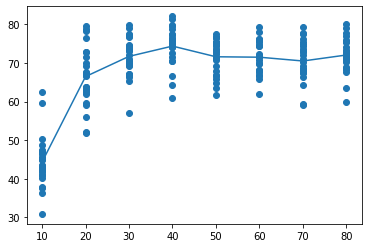

In [60]:
trend = pd.DataFrame(trend_data)
agg = trend.groupby('max_n').mean().reset_index()
plt.plot(agg['max_n'], 100*agg['p'])
plt.scatter(trend['max_n'], 100*trend['p'])

In [61]:
agg

,max_n,p
0,10,0.443498
1,20,0.664792
2,30,0.717113
3,40,0.743755
4,50,0.716107
5,60,0.714993
6,70,0.705173
7,80,0.720667
